In [15]:
# ============================================================
# SECTION 1: PROJECT HEADER
# ============================================================

"""
Project:
Multi-Agent AI Framework for Fossil Fuel Displacement

Agent:
Grid Stability Agent

Goal:
Predict whether the electrical grid is Stable or Unstable and estimate numerical stability score.

Dataset:
UCI Grid Stability Dataset

Main Outputs:
1. grid_classification_best_model.pkl
2. grid_regression_best_model.pkl
3. grid_agent.pkl
4. grid_agent_output.json
5. coordinator_grid_output.json
6. grid_research_report.xlsx
7. grid_dashboard.png
"""

'\nProject:\nMulti-Agent AI Framework for Fossil Fuel Displacement\n\nAgent:\nGrid Stability Agent\n\nGoal:\nPredict whether the electrical grid is Stable or Unstable and estimate numerical stability score.\n\nDataset:\nUCI Grid Stability Dataset\n\nMain Outputs:\n1. grid_classification_best_model.pkl\n2. grid_regression_best_model.pkl\n3. grid_agent.pkl\n4. grid_agent_output.json\n5. coordinator_grid_output.json\n6. grid_research_report.xlsx\n7. grid_dashboard.png\n'

In [16]:
# ============================================================
# SECTION 2: LIBRARY IMPORTS
# ============================================================

import os
import sys
import json
import time
import platform
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import xgboost

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    cross_val_score,
    learning_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    VotingClassifier,
    VotingRegressor,
    StackingClassifier,
    StackingRegressor,
    IsolationForest
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

from xgboost import XGBClassifier, XGBRegressor

import joblib

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
N_SPLITS = 5

ENABLE_SHAP = True
ENABLE_LEARNING_CURVE = True

In [17]:
# ============================================================
# SECTION 3: DATASET PATH
# ============================================================

DATASET_FOLDER = r"E:\Multi_agentic_AI_Project\Dataset\Grid Stability dataset"
DATASET_FILE = "Data_for_UCI_named.csv"

DATASET_PATH = os.path.join(DATASET_FOLDER, DATASET_FILE)

if not os.path.exists(DATASET_PATH):
    csv_files = [
        file for file in os.listdir(DATASET_FOLDER)
        if file.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        raise FileNotFoundError("No CSV file found in Grid Stability dataset folder.")

    DATASET_PATH = os.path.join(DATASET_FOLDER, csv_files[0])

print("Dataset Path:", DATASET_PATH)

Dataset Path: E:\Multi_agentic_AI_Project\Dataset\Grid Stability dataset\Data_for_UCI_named.csv


In [18]:
# ============================================================
# SECTION 4: HELPER FUNCTIONS
# ============================================================

def save_json(data, file_name):
    with open(file_name, "w") as file:
        json.dump(data, file, indent=4)


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


def overfitting_label(train_score, test_score):
    gap = train_score - test_score

    if gap <= 0.05:
        return "Good Fit"
    elif gap <= 0.10:
        return "Slight Overfitting"
    else:
        return "Severe Overfitting"


def create_feature_row_from_dict(input_data, selected_features, reference_df):
    input_df = pd.DataFrame([input_data])

    for feature in selected_features:
        if feature not in input_df.columns:
            input_df[feature] = reference_df[feature].median()

    return input_df[selected_features]

In [19]:
# ============================================================
# SECTION 5: DATA LOADING
# ============================================================

grid_df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully")
print("Shape:", grid_df.shape)

display(grid_df.head())

Dataset loaded successfully
Shape: (10000, 14)


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [20]:
# ============================================================
# SECTION 6: DATASET INSPECTION
# ============================================================

print("Columns:")
print(grid_df.columns.tolist())

print("\nDataset Info:")
display(grid_df.info())

print("\nMissing Values:")
display(grid_df.isnull().sum())

print("\nStatistical Summary:")
display(grid_df.describe())

print("\nDuplicate Rows:", grid_df.duplicated().sum())

Columns:
['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stab', 'stabf']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


None


Missing Values:


tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64


Statistical Summary:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



Duplicate Rows: 0


In [21]:
# ============================================================
# SECTION 7: DATA CLEANING
# ============================================================

grid_df = grid_df.drop_duplicates().copy()

grid_df.columns = grid_df.columns.str.strip()

for col in grid_df.columns:
    if col != "stabf":
        grid_df[col] = pd.to_numeric(grid_df[col], errors="coerce")

grid_df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in grid_df.select_dtypes(include=["number"]).columns:
    grid_df[col] = grid_df[col].fillna(grid_df[col].median())

if "stabf" not in grid_df.columns:
    raise ValueError("Column 'stabf' not found.")

if "stab" not in grid_df.columns:
    raise ValueError("Column 'stab' not found.")

grid_df["stabf"] = grid_df["stabf"].astype(str).str.lower().str.strip()

grid_df["stabf_encoded"] = grid_df["stabf"].map({
    "stable": 1,
    "unstable": 0
})

if grid_df["stabf_encoded"].isnull().sum() > 0:
    raise ValueError("Unknown labels found in stabf column.")

print("Data cleaning completed")
display(grid_df.head())

Data cleaning completed


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf,stabf_encoded
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable,0
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable,1
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable,0
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable,0
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable,0


Class Distribution:


stabf
unstable    6380
stable      3620
Name: count, dtype: int64

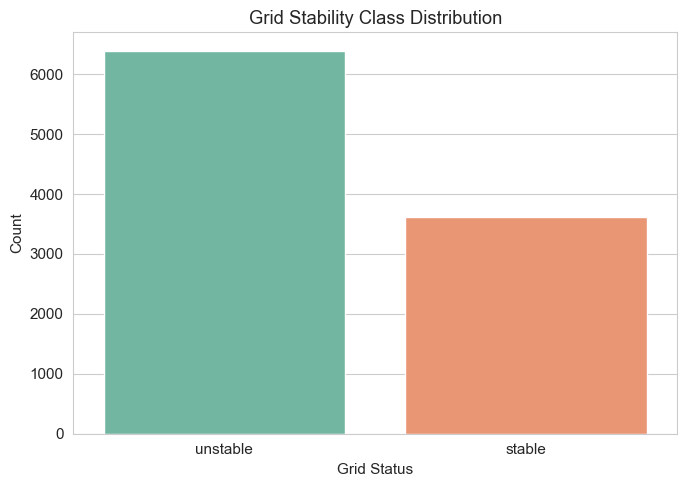

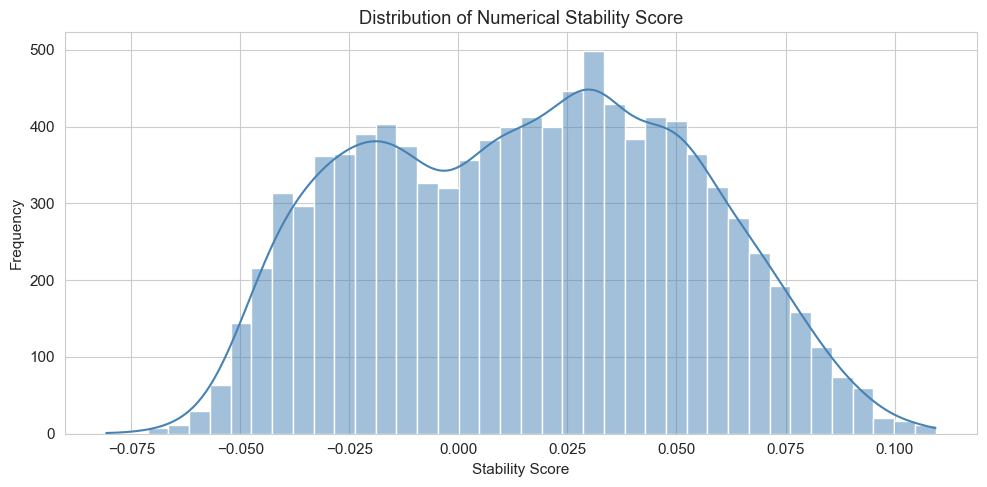

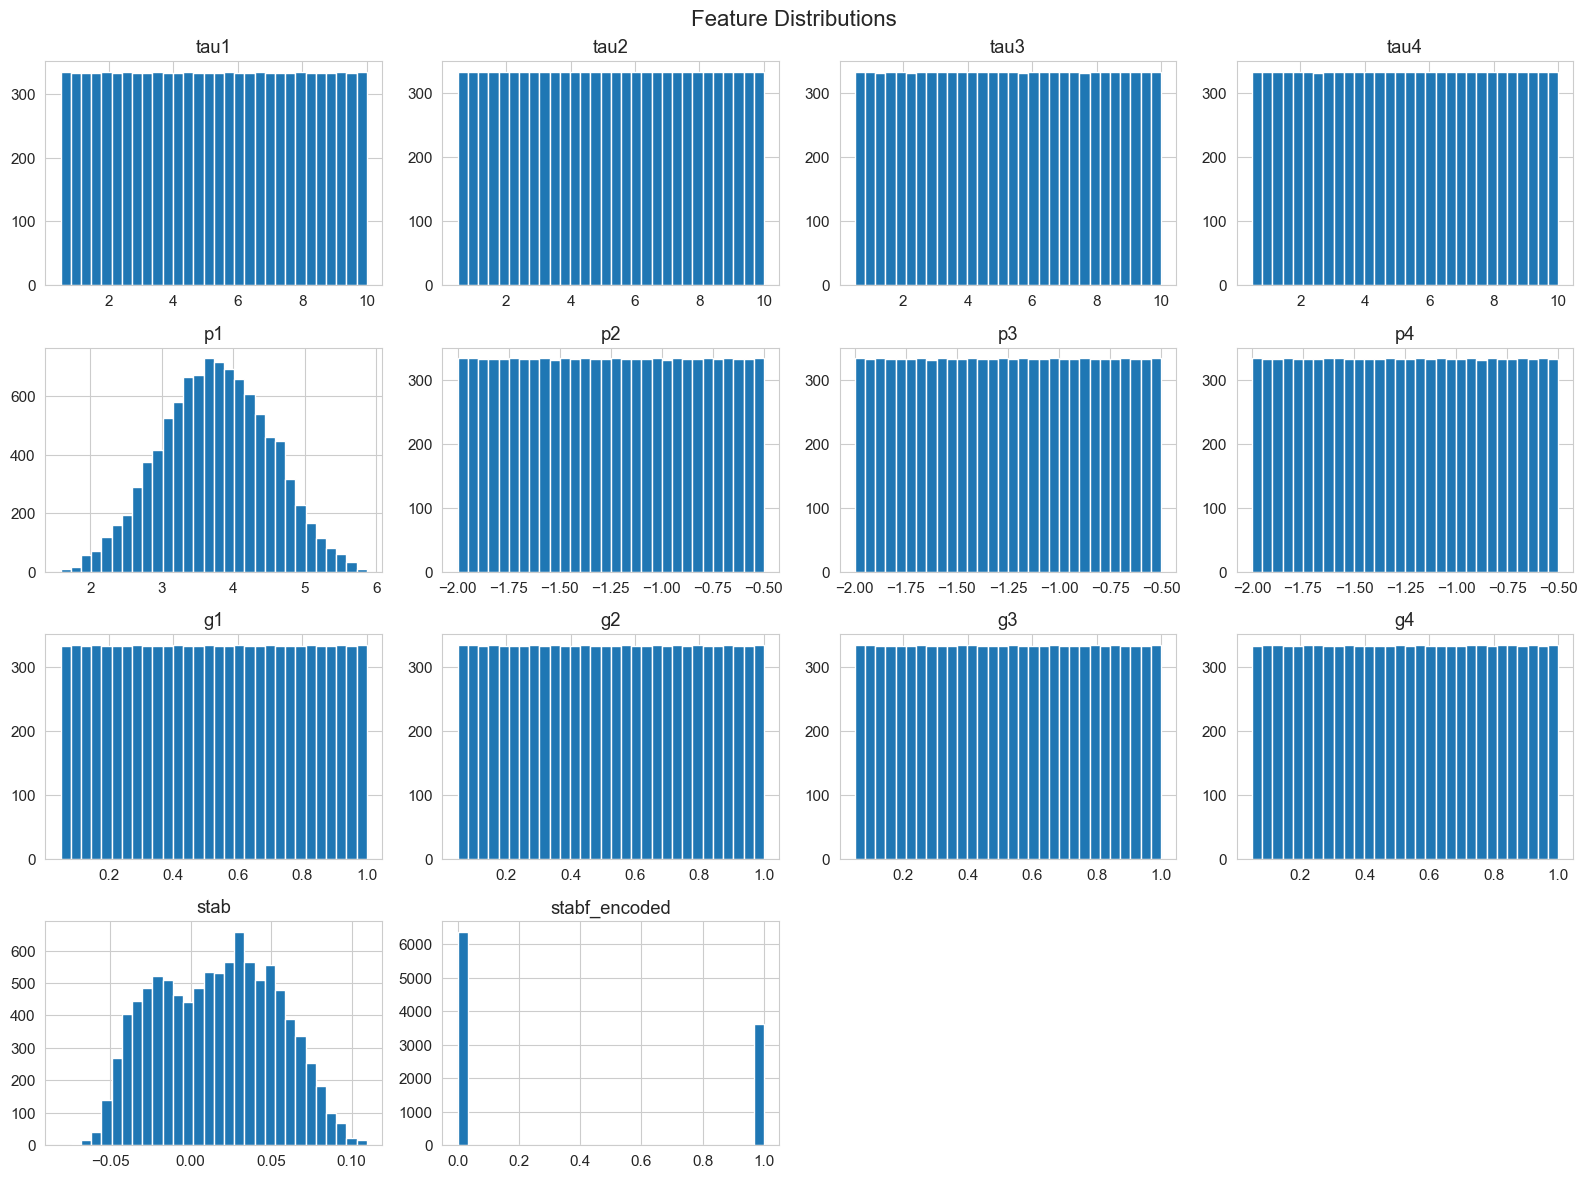

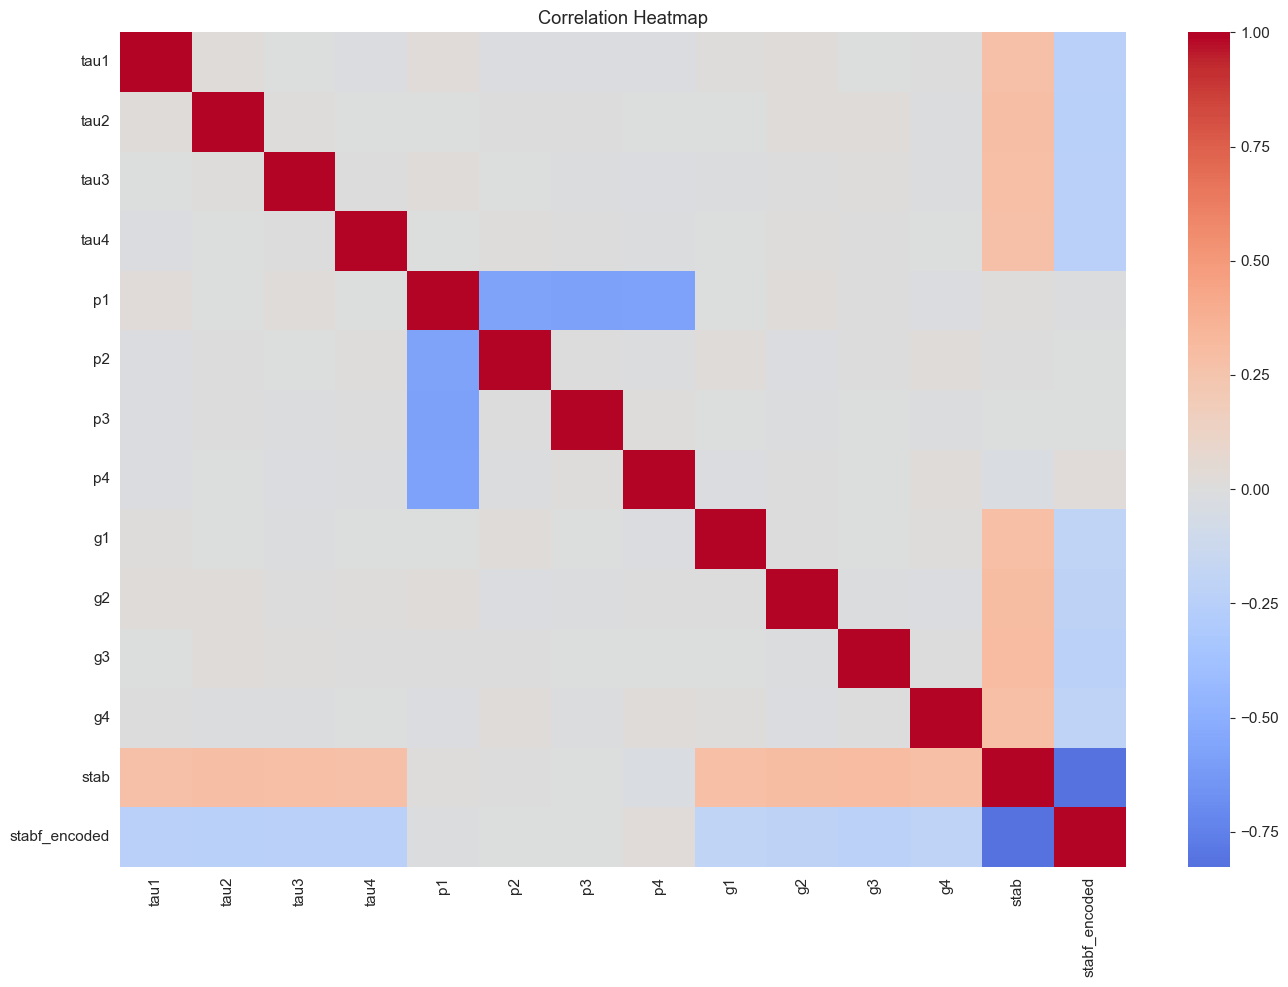

stab             1.000000
g3               0.308235
g2               0.293601
tau2             0.290975
g1               0.282774
tau3             0.280700
g4               0.279214
tau4             0.278576
tau1             0.275761
p1               0.010278
p2               0.006255
p3              -0.003321
p4              -0.020786
stabf_encoded   -0.826959
Name: stab, dtype: float64

In [22]:
# ============================================================
# SECTION 8: EXPLORATORY DATA ANALYSIS
# ============================================================

print("Class Distribution:")
display(grid_df["stabf"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=grid_df, x="stabf", palette="Set2")
plt.title("Grid Stability Class Distribution")
plt.xlabel("Grid Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(grid_df["stab"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Numerical Stability Score")
plt.xlabel("Stability Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

numeric_cols = grid_df.select_dtypes(include=["number"]).columns.tolist()

grid_df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
corr = grid_df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

correlation_with_stability = corr["stab"].sort_values(ascending=False)
display(correlation_with_stability)

correlation_with_stability.to_csv("grid_feature_correlation.csv")

,Feature,IQR_Outliers,ZScore_Outliers,Lower_Bound,Upper_Bound
0,tau1,0,0,-4.249806,14.749387
1,tau2,0,0,-4.249490,14.749523
2,tau3,0,0,-4.248618,14.749088
3,tau4,0,0,-4.249881,14.749669
4,p1,1,0,1.622119,5.878601
5,p2,0,0,-2.749788,0.249910
6,p3,0,0,-2.749999,0.249930
7,p4,0,0,-2.749802,0.249778
8,g1,0,0,-0.424849,1.474805
9,g2,0,0,-0.424856,1.474898


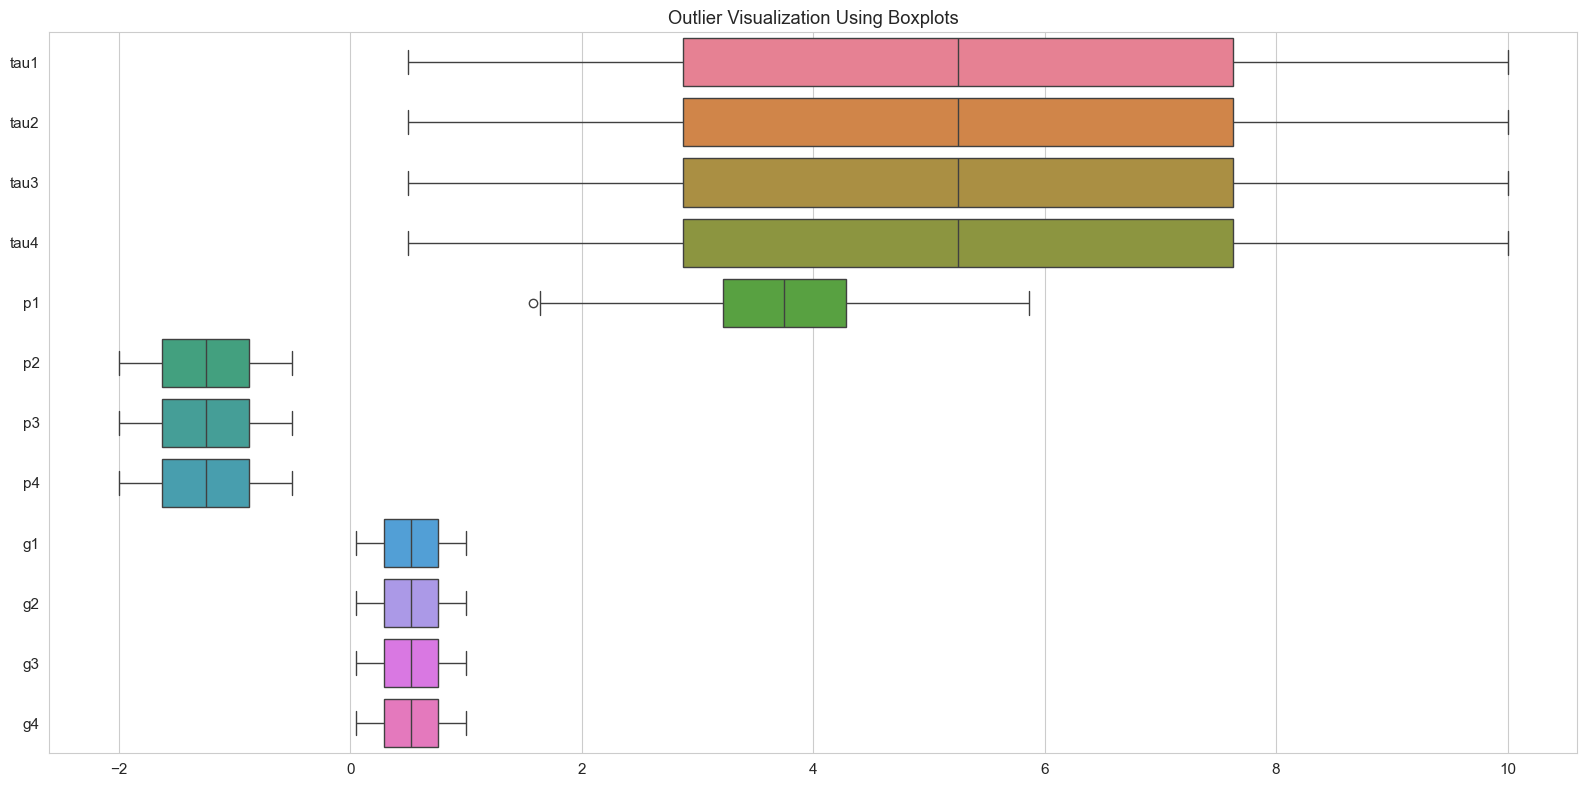

Isolation Forest Outliers: 500
Conclusion: Outliers are NOT removed because abnormal values may represent real unstable grid operating conditions.


In [23]:
# ============================================================
# SECTION 9: OUTLIER DETECTION REPORT
# ============================================================

outlier_rows = []

feature_cols_for_outliers = [
    col for col in numeric_cols
    if col not in ["stab", "stabf_encoded"]
]

for col in feature_cols_for_outliers:
    q1 = grid_df[col].quantile(0.25)
    q3 = grid_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    iqr_outliers = grid_df[
        (grid_df[col] < lower_bound) |
        (grid_df[col] > upper_bound)
    ].shape[0]

    z_scores = np.abs((grid_df[col] - grid_df[col].mean()) / grid_df[col].std())
    z_outliers = (z_scores > 3).sum()

    outlier_rows.append({
        "Feature": col,
        "IQR_Outliers": int(iqr_outliers),
        "ZScore_Outliers": int(z_outliers),
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

grid_outlier_report = pd.DataFrame(outlier_rows)

display(grid_outlier_report)

grid_outlier_report.to_csv("grid_outlier_report.csv", index=False)

plt.figure(figsize=(16, 8))
sns.boxplot(data=grid_df[feature_cols_for_outliers], orient="h")
plt.title("Outlier Visualization Using Boxplots")
plt.tight_layout()
plt.show()

iso = IsolationForest(
    contamination=0.05,
    random_state=RANDOM_STATE
)

grid_df["isolation_outlier"] = iso.fit_predict(grid_df[feature_cols_for_outliers])
isolation_outlier_count = (grid_df["isolation_outlier"] == -1).sum()

print("Isolation Forest Outliers:", isolation_outlier_count)
print("Conclusion: Outliers are NOT removed because abnormal values may represent real unstable grid operating conditions.")

In [24]:
# ============================================================
# SECTION 10: FEATURE ENGINEERING
# ============================================================

base_features = [
    "tau1", "tau2", "tau3", "tau4",
    "p1", "p2", "p3", "p4",
    "g1", "g2", "g3", "g4"
]

missing_features = [col for col in base_features if col not in grid_df.columns]

if missing_features:
    raise ValueError(f"Missing expected features: {missing_features}")

grid_df["TAU_MEAN"] = grid_df[["tau1", "tau2", "tau3", "tau4"]].mean(axis=1)
grid_df["TAU_STD"] = grid_df[["tau1", "tau2", "tau3", "tau4"]].std(axis=1)

grid_df["P_SUM"] = grid_df[["p1", "p2", "p3", "p4"]].sum(axis=1)
grid_df["P_ABS_SUM"] = grid_df[["p1", "p2", "p3", "p4"]].abs().sum(axis=1)

grid_df["G_MEAN"] = grid_df[["g1", "g2", "g3", "g4"]].mean(axis=1)
grid_df["G_STD"] = grid_df[["g1", "g2", "g3", "g4"]].std(axis=1)

grid_df["TAU_G_INTERACTION"] = grid_df["TAU_MEAN"] * grid_df["G_MEAN"]
grid_df["POWER_BALANCE_ERROR"] = grid_df["P_SUM"].abs()

engineered_features = [
    "TAU_MEAN",
    "TAU_STD",
    "P_SUM",
    "P_ABS_SUM",
    "G_MEAN",
    "G_STD",
    "TAU_G_INTERACTION",
    "POWER_BALANCE_ERROR"
]

all_features = base_features + engineered_features

classification_target = "stabf_encoded"
regression_target = "stab"

print("Total Features:", len(all_features))
print(all_features)

Total Features: 20
['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'TAU_MEAN', 'TAU_STD', 'P_SUM', 'P_ABS_SUM', 'G_MEAN', 'G_STD', 'TAU_G_INTERACTION', 'POWER_BALANCE_ERROR']


In [25]:
# ============================================================
# SECTION 11: FEATURE SELECTION
# ============================================================

X_all = grid_df[all_features].copy()
y_class = grid_df[classification_target].copy()
y_reg = grid_df[regression_target].copy()

mi_class = mutual_info_classif(
    X_all,
    y_class,
    random_state=RANDOM_STATE
)

mi_reg = mutual_info_regression(
    X_all,
    y_reg,
    random_state=RANDOM_STATE
)

feature_ranking = pd.DataFrame({
    "Feature": all_features,
    "MI_Classification": mi_class,
    "MI_Regression": mi_reg
})

feature_ranking["MI_Average"] = (
    feature_ranking["MI_Classification"] +
    feature_ranking["MI_Regression"]
) / 2

feature_ranking = feature_ranking.sort_values(
    by="MI_Average",
    ascending=False
).reset_index(drop=True)

display(feature_ranking)

feature_ranking.to_csv("grid_feature_ranking.csv", index=False)

selected_features = feature_ranking.head(12)["Feature"].tolist()

pd.DataFrame({"Feature": selected_features}).to_csv(
    "grid_selected_features.csv",
    index=False
)

print("Selected Features:")
print(selected_features)

,Feature,MI_Classification,MI_Regression,MI_Average
0,TAU_G_INTERACTION,0.262761,0.535026,0.398893
1,G_MEAN,0.105999,0.322649,0.214324
2,TAU_MEAN,0.130344,0.198436,0.164390
3,TAU_STD,0.041052,0.101159,0.071106
4,tau1,0.040263,0.088005,0.064134
5,tau2,0.035675,0.077847,0.056761
6,tau4,0.043882,0.058510,0.051196
7,tau3,0.034338,0.065525,0.049931
8,g3,0.027905,0.058739,0.043322
9,g1,0.020657,0.060127,0.040392


Selected Features:
['TAU_G_INTERACTION', 'G_MEAN', 'TAU_MEAN', 'TAU_STD', 'tau1', 'tau2', 'tau4', 'tau3', 'g3', 'g1', 'g2', 'g4']


In [26]:
# ============================================================
# SECTION 12: TRAIN TEST SPLIT AND CLASS IMBALANCE CHECK
# ============================================================

X = grid_df[selected_features].copy()

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_class
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

classification_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

regression_cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

class_counts = y_class_train.value_counts(normalize=True)
majority_ratio = class_counts.max()

print("Training Class Distribution:")
display(y_class_train.value_counts())
print("Majority Class Ratio:", majority_ratio)

apply_smote = majority_ratio > 0.70 and IMBLEARN_AVAILABLE

if apply_smote:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_class_train_model, y_class_train_model = smote.fit_resample(
        X_class_train,
        y_class_train
    )
    print("SMOTE applied because class imbalance is above 70:30.")
else:
    X_class_train_model = X_class_train.copy()
    y_class_train_model = y_class_train.copy()
    print("SMOTE not applied. Class balance is acceptable or imblearn is unavailable.")

Training Class Distribution:


stabf_encoded
0    5104
1    2896
Name: count, dtype: int64

Majority Class Ratio: 0.638
SMOTE not applied. Class balance is acceptable or imblearn is unavailable.


In [27]:
# ============================================================
# SECTION 13: CLASSIFICATION HYPERPARAMETER TUNING
# ============================================================

rf_class_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

xgb_class_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 1.0]
}

rf_class_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_class_params,
    cv=classification_cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_class_grid.fit(X_class_train_model, y_class_train_model)

xgb_class_grid = GridSearchCV(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    xgb_class_params,
    cv=classification_cv,
    scoring="accuracy",
    n_jobs=-1
)

xgb_class_grid.fit(X_class_train_model, y_class_train_model)

best_rf_classifier = rf_class_grid.best_estimator_
best_xgb_classifier = xgb_class_grid.best_estimator_

pd.DataFrame([rf_class_grid.best_params_]).to_csv(
    "grid_best_params_rf_classification.csv",
    index=False
)

pd.DataFrame([xgb_class_grid.best_params_]).to_csv(
    "grid_best_params_xgb_classification.csv",
    index=False
)

print("Best RF Classification Params:", rf_class_grid.best_params_)
print("Best XGB Classification Params:", xgb_class_grid.best_params_)

Best RF Classification Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best XGB Classification Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [28]:
# ============================================================
# SECTION 14: REGRESSION HYPERPARAMETER TUNING
# ============================================================

rf_reg_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

xgb_reg_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 1.0]
}

rf_reg_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_reg_params,
    cv=regression_cv,
    scoring="r2",
    n_jobs=-1
)

rf_reg_grid.fit(X_reg_train, y_reg_train)

xgb_reg_grid = GridSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    xgb_reg_params,
    cv=regression_cv,
    scoring="r2",
    n_jobs=-1
)

xgb_reg_grid.fit(X_reg_train, y_reg_train)

best_rf_regressor = rf_reg_grid.best_estimator_
best_xgb_regressor = xgb_reg_grid.best_estimator_

pd.DataFrame([rf_reg_grid.best_params_]).to_csv(
    "grid_best_params_rf_regression.csv",
    index=False
)

pd.DataFrame([xgb_reg_grid.best_params_]).to_csv(
    "grid_best_params_xgb_regression.csv",
    index=False
)

print("Best RF Regression Params:", rf_reg_grid.best_params_)
print("Best XGB Regression Params:", xgb_reg_grid.best_params_)

Best RF Regression Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best XGB Regression Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [29]:
# ============================================================
# SECTION 15: CLASSIFICATION MODELS
# ============================================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

voting_classifier = VotingClassifier(
    estimators=[
        ("lr", logistic_model),
        ("rf", best_rf_classifier),
        ("xgb", best_xgb_classifier)
    ],
    voting="soft",
    n_jobs=-1
)

stacking_classifier = StackingClassifier(
    estimators=[
        ("rf", best_rf_classifier),
        ("xgb", best_xgb_classifier)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

classification_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": best_rf_classifier,
    "XGBoost": best_xgb_classifier,
    "Voting Classifier": voting_classifier,
    "Stacking Classifier": stacking_classifier
}

classification_results = []

for model_name, model in classification_models.items():
    start_train = time.time()
    model.fit(X_class_train_model, y_class_train_model)
    training_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_class_test)
    prediction_time = time.time() - start_pred

    train_pred = model.predict(X_class_train)
    train_accuracy = accuracy_score(y_class_train, train_pred)
    test_accuracy = accuracy_score(y_class_test, y_pred)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_class_test)[:, 1]
        roc_auc = roc_auc_score(y_class_test, y_prob)
    else:
        roc_auc = np.nan

    cv_scores = cross_val_score(
        model,
        X,
        y_class,
        cv=classification_cv,
        scoring="accuracy",
        n_jobs=-1
    )

    classification_results.append({
        "Task": "Classification",
        "Model": model_name,
        "Train_Accuracy": train_accuracy,
        "Test_Accuracy": test_accuracy,
        "Accuracy": test_accuracy,
        "Precision": precision_score(y_class_test, y_pred),
        "Recall": recall_score(y_class_test, y_pred),
        "F1": f1_score(y_class_test, y_pred),
        "ROC_AUC": roc_auc,
        "CV_Mean": cv_scores.mean(),
        "CV_Std": cv_scores.std(),
        "Overfitting_Gap": train_accuracy - test_accuracy,
        "Fit_Status": overfitting_label(train_accuracy, test_accuracy),
        "Training_Time": training_time,
        "Prediction_Time": prediction_time
    })

classification_results_df = pd.DataFrame(classification_results)

classification_ranking = classification_results_df.sort_values(
    by=["CV_Mean", "ROC_AUC", "F1"],
    ascending=[False, False, False]
).reset_index(drop=True)

classification_ranking["Rank"] = range(1, len(classification_ranking) + 1)

display(classification_ranking)

best_classification_model_name = classification_ranking.loc[0, "Model"]
best_classification_model = classification_models[best_classification_model_name]

print("Best Classification Model:", best_classification_model_name)

,Task,Model,Train_Accuracy,Test_Accuracy,Accuracy,Precision,Recall,F1,ROC_AUC,CV_Mean,CV_Std,Overfitting_Gap,Fit_Status,Training_Time,Prediction_Time,Rank
0,Classification,XGBoost,0.985875,0.9360,0.9360,0.918539,0.903315,0.910864,0.983835,0.9388,0.002786,0.049875,Good Fit,0.923635,0.017249,1
1,Classification,Stacking Classifier,0.985125,0.9295,0.9295,0.911142,0.892265,0.901605,0.982583,0.9379,0.003105,0.055625,Slight Overfitting,16.546661,0.196378,2
2,Classification,Random Forest,1.000000,0.9190,0.9190,0.899148,0.874309,0.886555,0.976896,0.9217,0.007626,0.081000,Slight Overfitting,3.034232,0.188426,3
3,Classification,Voting Classifier,0.978250,0.9155,0.9155,0.882759,0.883978,0.883368,0.975187,0.9198,0.005446,0.062750,Slight Overfitting,3.621015,0.155838,4
4,Classification,Logistic Regression,0.869750,0.8615,0.8615,0.817021,0.795580,0.806158,0.944957,0.8673,0.010018,0.008250,Good Fit,0.059377,0.005640,5


Best Classification Model: XGBoost


In [30]:
# ============================================================
# SECTION 16: REGRESSION MODELS
# ============================================================

linear_regression = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

voting_regressor = VotingRegressor(
    estimators=[
        ("rf", best_rf_regressor),
        ("xgb", best_xgb_regressor)
    ],
    n_jobs=-1
)

stacking_regressor = StackingRegressor(
    estimators=[
        ("rf", best_rf_regressor),
        ("xgb", best_xgb_regressor)
    ],
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

regression_models = {
    "Linear Regression": linear_regression,
    "Random Forest": best_rf_regressor,
    "XGBoost": best_xgb_regressor,
    "Voting Regressor": voting_regressor,
    "Stacking Regressor": stacking_regressor
}

regression_results = []

for model_name, model in regression_models.items():
    start_train = time.time()
    model.fit(X_reg_train, y_reg_train)
    training_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_reg_test)
    prediction_time = time.time() - start_pred

    train_pred = model.predict(X_reg_train)

    train_r2 = r2_score(y_reg_train, train_pred)
    test_r2 = r2_score(y_reg_test, y_pred)

    metrics = regression_metrics(y_reg_test, y_pred)

    cv_scores = cross_val_score(
        model,
        X,
        y_reg,
        cv=regression_cv,
        scoring="r2",
        n_jobs=-1
    )

    regression_results.append({
        "Task": "Regression",
        "Model": model_name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
        "CV_Mean": cv_scores.mean(),
        "CV_Std": cv_scores.std(),
        "Overfitting_Gap": train_r2 - test_r2,
        "Fit_Status": overfitting_label(train_r2, test_r2),
        "Training_Time": training_time,
        "Prediction_Time": prediction_time
    })

regression_results_df = pd.DataFrame(regression_results)

regression_ranking = regression_results_df.sort_values(
    by=["CV_Mean", "R2", "RMSE"],
    ascending=[False, False, True]
).reset_index(drop=True)

regression_ranking["Rank"] = range(1, len(regression_ranking) + 1)

display(regression_ranking)

best_regression_model_name = regression_ranking.loc[0, "Model"]
best_regression_model = regression_models[best_regression_model_name]

print("Best Regression Model:", best_regression_model_name)

,Task,Model,Train_R2,Test_R2,MAE,RMSE,R2,CV_Mean,CV_Std,Overfitting_Gap,Fit_Status,Training_Time,Prediction_Time,Rank
0,Regression,Stacking Regressor,0.955623,0.952317,0.005900,0.008042,0.952317,0.954221,0.002740,0.003306,Good Fit,75.058764,0.190867,1
1,Regression,XGBoost,0.970021,0.945519,0.006378,0.008596,0.945519,0.945928,0.002509,0.024503,Good Fit,0.950915,0.009448,2
2,Regression,Voting Regressor,0.979649,0.920409,0.007698,0.010390,0.920409,0.922703,0.002721,0.059240,Slight Overfitting,16.129719,0.198902,3
3,Regression,Random Forest,0.984134,0.880313,0.009461,0.012741,0.880313,0.884478,0.004484,0.103821,Severe Overfitting,13.704681,0.195575,4
4,Regression,Linear Regression,0.774958,0.769873,0.014192,0.017667,0.769873,0.773167,0.006107,0.005085,Good Fit,0.028662,0.005004,5


Best Regression Model: Stacking Regressor


In [31]:
# ============================================================
# SECTION 17: OVERFITTING ANALYSIS
# ============================================================

classification_overfitting = classification_ranking[
    [
        "Model",
        "Train_Accuracy",
        "Test_Accuracy",
        "CV_Mean",
        "Overfitting_Gap",
        "Fit_Status"
    ]
]

regression_overfitting = regression_ranking[
    [
        "Model",
        "Train_R2",
        "Test_R2",
        "CV_Mean",
        "Overfitting_Gap",
        "Fit_Status"
    ]
]

display(classification_overfitting)
display(regression_overfitting)

classification_overfitting.to_csv(
    "grid_classification_overfitting_report.csv",
    index=False
)

regression_overfitting.to_csv(
    "grid_regression_overfitting_report.csv",
    index=False
)

,Model,Train_Accuracy,Test_Accuracy,CV_Mean,Overfitting_Gap,Fit_Status
0,XGBoost,0.985875,0.9360,0.9388,0.049875,Good Fit
1,Stacking Classifier,0.985125,0.9295,0.9379,0.055625,Slight Overfitting
2,Random Forest,1.000000,0.9190,0.9217,0.081000,Slight Overfitting
3,Voting Classifier,0.978250,0.9155,0.9198,0.062750,Slight Overfitting
4,Logistic Regression,0.869750,0.8615,0.8673,0.008250,Good Fit


,Model,Train_R2,Test_R2,CV_Mean,Overfitting_Gap,Fit_Status
0,Stacking Regressor,0.955623,0.952317,0.954221,0.003306,Good Fit
1,XGBoost,0.970021,0.945519,0.945928,0.024503,Good Fit
2,Voting Regressor,0.979649,0.920409,0.922703,0.059240,Slight Overfitting
3,Random Forest,0.984134,0.880313,0.884478,0.103821,Severe Overfitting
4,Linear Regression,0.774958,0.769873,0.773167,0.005085,Good Fit


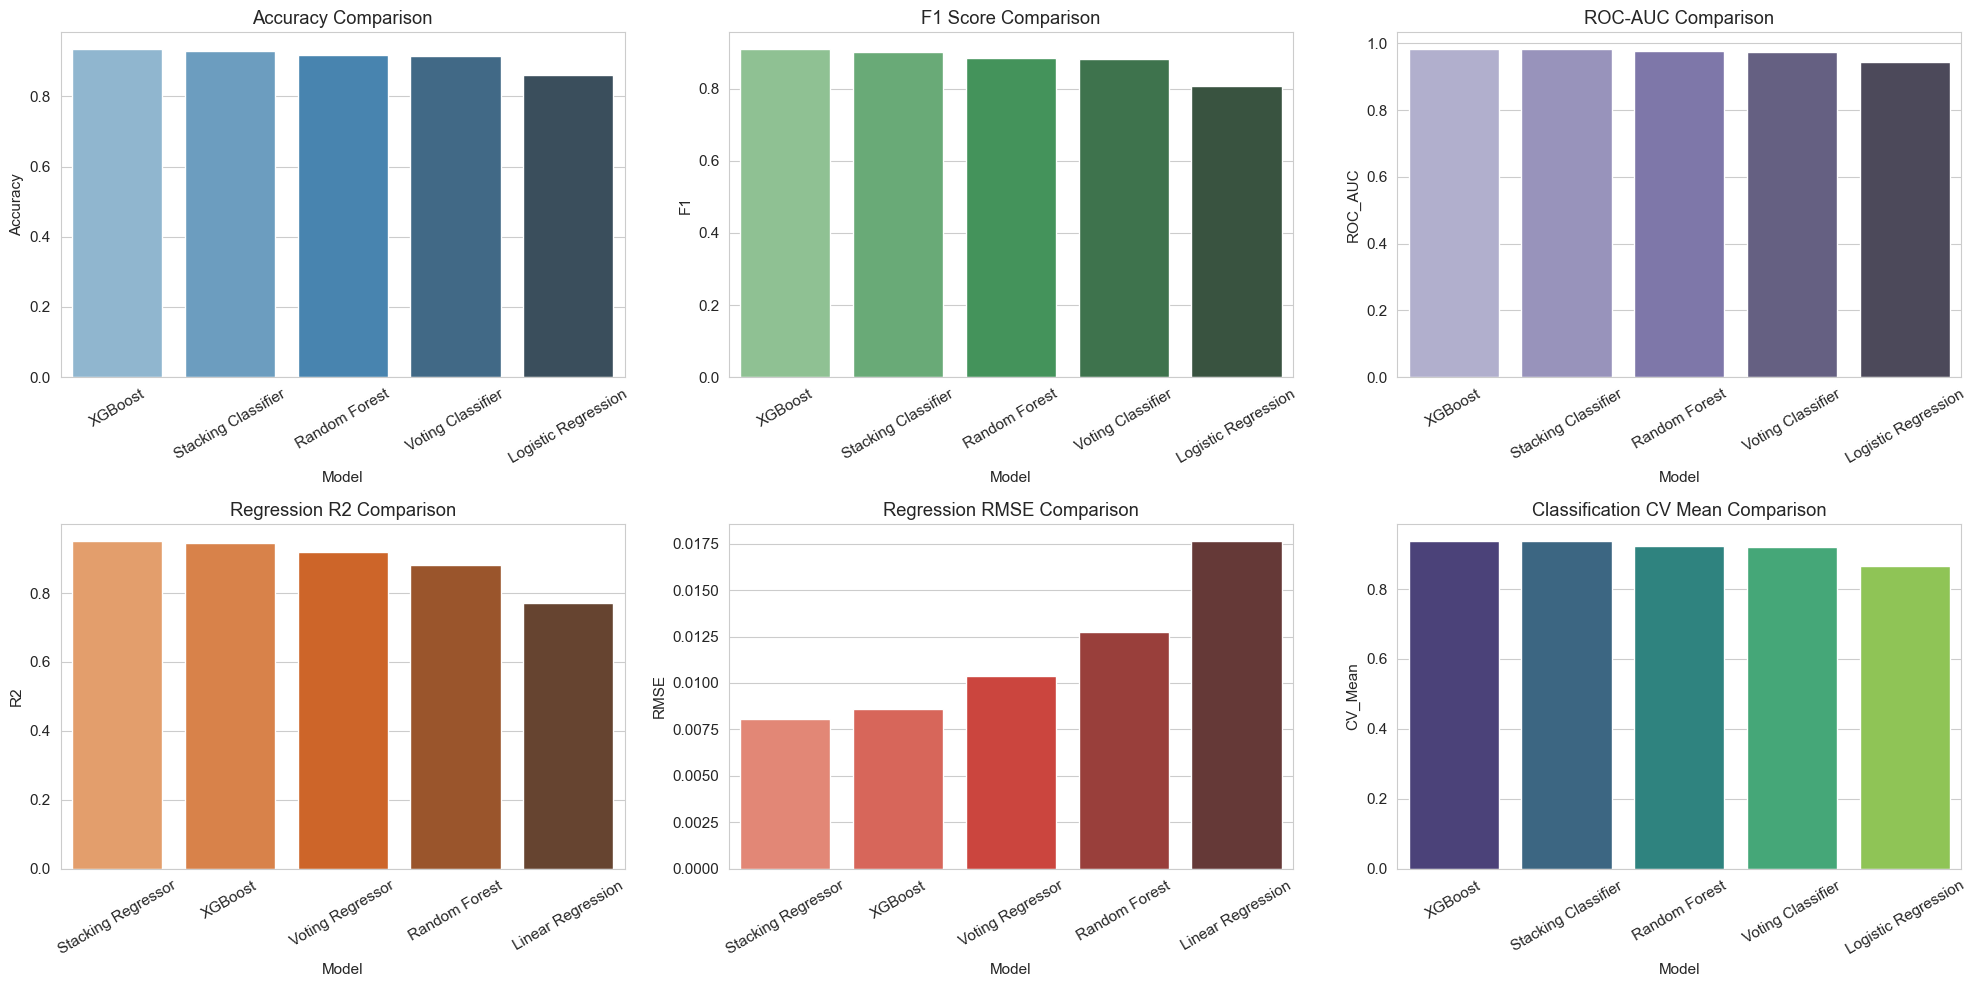

In [32]:
# ============================================================
# SECTION 18: MODEL COMPARISON VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.barplot(data=classification_ranking, x="Model", y="Accuracy", ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("Accuracy Comparison")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=classification_ranking, x="Model", y="F1", ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title("F1 Score Comparison")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.barplot(data=classification_ranking, x="Model", y="ROC_AUC", ax=axes[0, 2], palette="Purples_d")
axes[0, 2].set_title("ROC-AUC Comparison")
axes[0, 2].tick_params(axis="x", rotation=30)

sns.barplot(data=regression_ranking, x="Model", y="R2", ax=axes[1, 0], palette="Oranges_d")
axes[1, 0].set_title("Regression R2 Comparison")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=regression_ranking, x="Model", y="RMSE", ax=axes[1, 1], palette="Reds_d")
axes[1, 1].set_title("Regression RMSE Comparison")
axes[1, 1].tick_params(axis="x", rotation=30)

sns.barplot(data=classification_ranking, x="Model", y="CV_Mean", ax=axes[1, 2], palette="viridis")
axes[1, 2].set_title("Classification CV Mean Comparison")
axes[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("grid_model_comparison_plots.png", dpi=300)
plt.show()

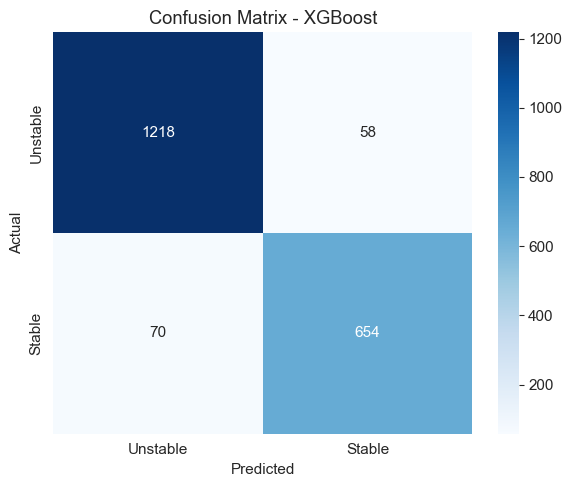

              precision    recall  f1-score   support

    Unstable       0.95      0.95      0.95      1276
      Stable       0.92      0.90      0.91       724

    accuracy                           0.94      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.94      0.94      0.94      2000



In [33]:
# ============================================================
# SECTION 19: CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

best_class_pred = best_classification_model.predict(X_class_test)

cm = confusion_matrix(y_class_test, best_class_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unstable", "Stable"],
    yticklabels=["Unstable", "Stable"]
)
plt.title(f"Confusion Matrix - {best_classification_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("grid_confusion_matrix.png", dpi=300)
plt.show()

print(classification_report(
    y_class_test,
    best_class_pred,
    target_names=["Unstable", "Stable"]
))

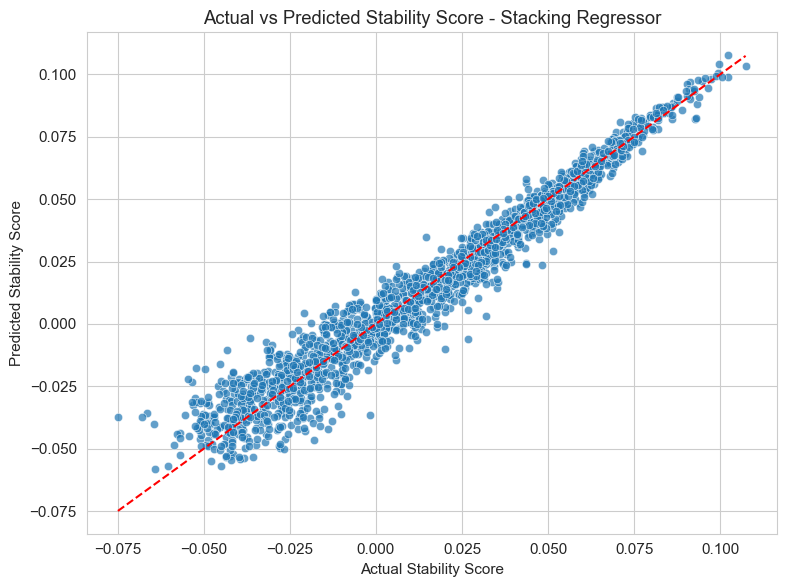

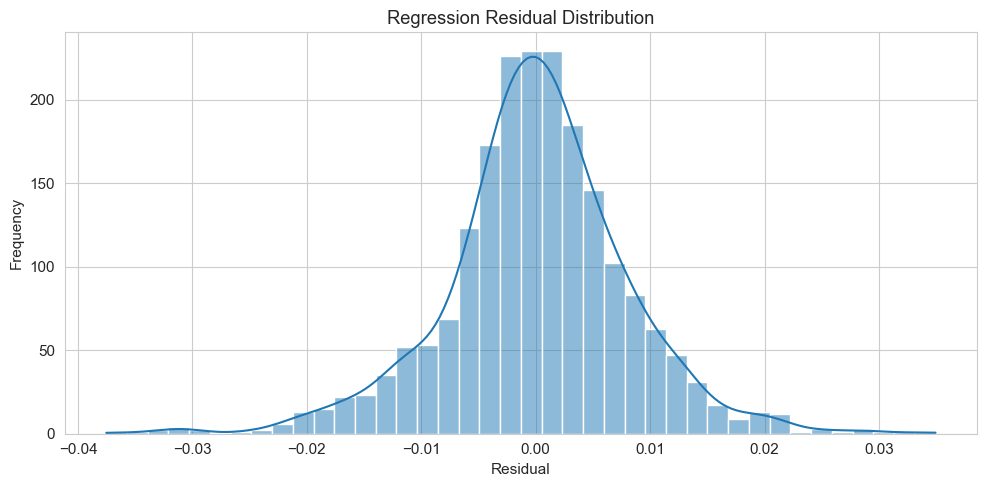

In [34]:
# ============================================================
# SECTION 20: REGRESSION ACTUAL VS PREDICTED
# ============================================================

best_reg_pred = best_regression_model.predict(X_reg_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_reg_test, y=best_reg_pred, alpha=0.7)
plt.plot(
    [y_reg_test.min(), y_reg_test.max()],
    [y_reg_test.min(), y_reg_test.max()],
    color="red",
    linestyle="--"
)
plt.title(f"Actual vs Predicted Stability Score - {best_regression_model_name}")
plt.xlabel("Actual Stability Score")
plt.ylabel("Predicted Stability Score")
plt.tight_layout()
plt.savefig("grid_actual_vs_predicted.png", dpi=300)
plt.show()

residuals = y_reg_test - best_reg_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Regression Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("grid_residual_distribution.png", dpi=300)
plt.show()

,Feature,Importance_Classification,Importance_Regression,Average_Importance
0,TAU_G_INTERACTION,0.401419,0.564080,0.482749
1,TAU_STD,0.155893,0.187036,0.171465
2,TAU_MEAN,0.059165,0.028821,0.043993
3,g2,0.055747,0.029593,0.042670
7,G_MEAN,0.040114,0.037301,0.038708
5,g1,0.048965,0.028391,0.038678
4,tau3,0.049878,0.025029,0.037453
6,g4,0.044798,0.030086,0.037442
8,g3,0.038111,0.020587,0.029349
9,tau1,0.036206,0.016078,0.026142


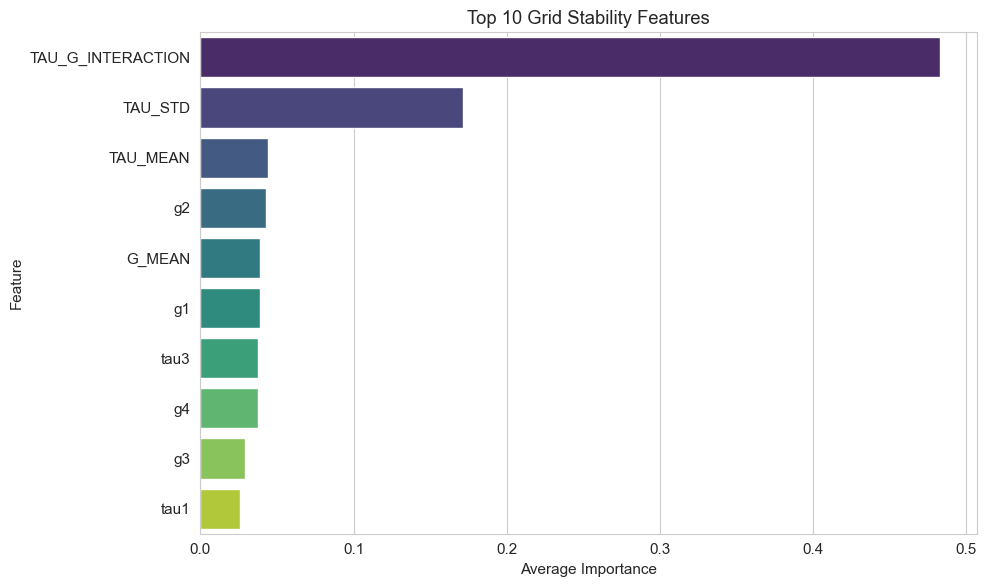

In [35]:
# ============================================================
# SECTION 21: FEATURE IMPORTANCE
# ============================================================

classification_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_xgb_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

regression_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_xgb_regressor.feature_importances_
}).sort_values(by="Importance", ascending=False)

grid_feature_importance = classification_importance.merge(
    regression_importance,
    on="Feature",
    suffixes=("_Classification", "_Regression")
)

grid_feature_importance["Average_Importance"] = (
    grid_feature_importance["Importance_Classification"] +
    grid_feature_importance["Importance_Regression"]
) / 2

grid_feature_importance = grid_feature_importance.sort_values(
    by="Average_Importance",
    ascending=False
)

display(grid_feature_importance)

grid_feature_importance.to_csv("grid_feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=grid_feature_importance.head(10),
    x="Average_Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 10 Grid Stability Features")
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("grid_feature_importance.png", dpi=300)
plt.show()

In [36]:
# ============================================================
# SECTION 22: SHAP EXPLAINABILITY
# ============================================================

if ENABLE_SHAP:
    try:
        import shap

        shap_sample = X_class_test.sample(
            n=min(300, len(X_class_test)),
            random_state=RANDOM_STATE
        )

        explainer = shap.TreeExplainer(best_xgb_classifier)
        shap_values = explainer.shap_values(shap_sample)

        if isinstance(shap_values, list):
            shap_array = shap_values[1]
        else:
            shap_array = shap_values

        shap_importance = pd.DataFrame({
            "Feature": shap_sample.columns,
            "Mean_Abs_SHAP": np.abs(shap_array).mean(axis=0)
        }).sort_values(by="Mean_Abs_SHAP", ascending=False)

        display(shap_importance)

        shap_importance.to_csv("grid_shap_feature_importance.csv", index=False)

        shap.summary_plot(shap_array, shap_sample, show=True)

    except Exception as e:
        shap_importance = pd.DataFrame(columns=["Feature", "Mean_Abs_SHAP"])
        shap_importance.to_csv("grid_shap_feature_importance.csv", index=False)
        print("SHAP skipped due to error:", e)
else:
    shap_importance = pd.DataFrame(columns=["Feature", "Mean_Abs_SHAP"])
    shap_importance.to_csv("grid_shap_feature_importance.csv", index=False)

SHAP skipped due to error: could not convert string to float: '[3.62E-1]'


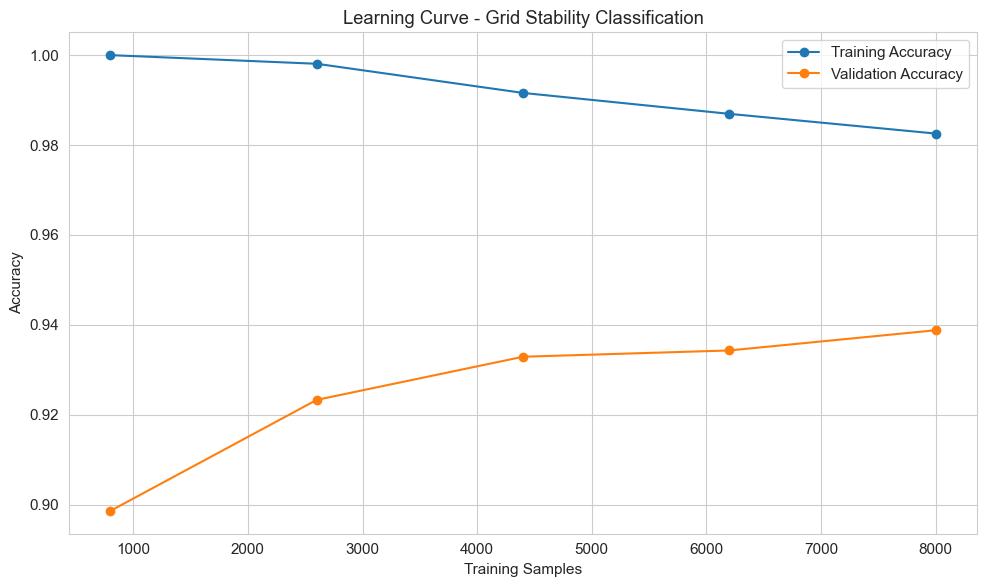

In [37]:
# ============================================================
# SECTION 23: LEARNING CURVE
# ============================================================

if ENABLE_LEARNING_CURVE:
    train_sizes, train_scores, validation_scores = learning_curve(
        best_classification_model,
        X,
        y_class,
        cv=classification_cv,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    plt.figure(figsize=(10, 6))
    plt.plot(
        train_sizes,
        train_scores.mean(axis=1),
        marker="o",
        label="Training Accuracy"
    )
    plt.plot(
        train_sizes,
        validation_scores.mean(axis=1),
        marker="o",
        label="Validation Accuracy"
    )
    plt.title("Learning Curve - Grid Stability Classification")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig("grid_learning_curve.png", dpi=300)
    plt.show()

In [38]:
# ============================================================
# SECTION 24: GRID STABILITY AGENT FUNCTION
# ============================================================

def grid_stability_agent(input_data):
    input_df = create_feature_row_from_dict(
        input_data,
        selected_features,
        X
    )

    prediction = int(best_classification_model.predict(input_df)[0])

    if hasattr(best_classification_model, "predict_proba"):
        proba = best_classification_model.predict_proba(input_df)[0]

        stability_probability = float(proba[1])
        confidence_score = float(np.max(proba))
    else:
        stability_probability = float(prediction)
        confidence_score = float(prediction)

    stability_score = float(best_regression_model.predict(input_df)[0])

    grid_status = "stable" if prediction == 1 else "unstable"

    if stability_probability >= 0.90:
        risk_level = "LOW"
        recommended_action = "Normal grid operation"
    elif stability_probability >= 0.70:
        risk_level = "MEDIUM"
        recommended_action = "Monitor voltage, load, and generation balance"
    elif stability_probability >= 0.50:
        risk_level = "HIGH"
        recommended_action = "Prepare corrective control and reserve support"
    else:
        risk_level = "CRITICAL"
        recommended_action = "Immediate grid stabilization required"

    return {
        "agent": "grid_stability",
        "status": "success",
        "grid_status": grid_status,
        "stability_score": stability_score,
        "stability_probability": stability_probability,
        "confidence_score": confidence_score,
        "risk_level": risk_level,
        "recommended_action": recommended_action,
        "classification_model": best_classification_model_name,
        "regression_model": best_regression_model_name,
        "timestamp": str(pd.Timestamp.now())
    }


latest_input = grid_df[selected_features].iloc[-1].to_dict()

grid_agent_output = grid_stability_agent(latest_input)

display(grid_agent_output)

{'agent': 'grid_stability',
 'status': 'success',
 'grid_status': 'unstable',
 'stability_score': 0.043788012241796265,
 'stability_probability': 0.0010397329460829496,
 'confidence_score': 0.9989602565765381,
 'risk_level': 'CRITICAL',
 'recommended_action': 'Immediate grid stabilization required',
 'classification_model': 'XGBoost',
 'regression_model': 'Stacking Regressor',
 'timestamp': '2026-06-26 01:49:10.009111'}

In [39]:
# ============================================================
# SECTION 25: ADVANCED STRESS TESTING
# ============================================================

stress_cases = []

feature_min = X.min()
feature_max = X.max()
feature_median = X.median()

stress_cases.append({
    "Scenario": "Normal Operating Condition",
    **feature_median.to_dict()
})

high_load = feature_median.copy()
for col in selected_features:
    if col.startswith("p"):
        high_load[col] = feature_max[col]
stress_cases.append({
    "Scenario": "High Load Condition",
    **high_load.to_dict()
})

low_generation = feature_median.copy()
for col in selected_features:
    if col.startswith("g"):
        low_generation[col] = feature_min[col]
stress_cases.append({
    "Scenario": "Low Generation Condition",
    **low_generation.to_dict()
})

extreme_condition = feature_median.copy()
for col in selected_features:
    extreme_condition[col] = feature_max[col] if np.random.rand() > 0.5 else feature_min[col]
stress_cases.append({
    "Scenario": "Extreme Grid Condition",
    **extreme_condition.to_dict()
})

for i in range(50):
    random_case = {
        feature: np.random.uniform(feature_min[feature], feature_max[feature])
        for feature in selected_features
    }
    random_case["Scenario"] = f"Random Synthetic Condition {i + 1}"
    stress_cases.append(random_case)

stress_test_results = []

for case in stress_cases:
    scenario_name = case.pop("Scenario")
    result = grid_stability_agent(case)
    result["Scenario"] = scenario_name
    stress_test_results.append(result)

stress_test_df = pd.DataFrame(stress_test_results)

display(stress_test_df.head())

stable_percent = (stress_test_df["grid_status"] == "stable").mean() * 100
unstable_percent = (stress_test_df["grid_status"] == "unstable").mean() * 100

stress_summary = pd.DataFrame({
    "Metric": [
        "Stable Percentage",
        "Unstable Percentage",
        "Average Stability Score",
        "Average Stability Probability",
        "Average Confidence"
    ],
    "Value": [
        stable_percent,
        unstable_percent,
        stress_test_df["stability_score"].mean(),
        stress_test_df["stability_probability"].mean(),
        stress_test_df["confidence_score"].mean()
    ]
})

display(stress_summary)

stress_test_df.to_csv("grid_agent_stress_test_results.csv", index=False)
stress_summary.to_csv("grid_agent_stress_test_summary.csv", index=False)

,agent,status,grid_status,stability_score,stability_probability,confidence_score,risk_level,recommended_action,classification_model,regression_model,timestamp,Scenario
0,grid_stability,success,unstable,0.019397,0.028289,0.971711,CRITICAL,Immediate grid stabilization required,XGBoost,Stacking Regressor,2026-06-26 01:49:10.206878,Normal Operating Condition
1,grid_stability,success,unstable,0.019397,0.028289,0.971711,CRITICAL,Immediate grid stabilization required,XGBoost,Stacking Regressor,2026-06-26 01:49:10.315719,High Load Condition
2,grid_stability,success,unstable,0.006633,0.297743,0.702257,CRITICAL,Immediate grid stabilization required,XGBoost,Stacking Regressor,2026-06-26 01:49:10.441525,Low Generation Condition
3,grid_stability,success,stable,-0.053308,0.978102,0.978102,LOW,Normal grid operation,XGBoost,Stacking Regressor,2026-06-26 01:49:10.549316,Extreme Grid Condition
4,grid_stability,success,unstable,0.051077,0.002105,0.997895,CRITICAL,Immediate grid stabilization required,XGBoost,Stacking Regressor,2026-06-26 01:49:10.940006,Random Synthetic Condition 1


,Metric,Value
0,Stable Percentage,29.629630
1,Unstable Percentage,70.370370
2,Average Stability Score,0.027618
3,Average Stability Probability,0.299770
4,Average Confidence,0.940750


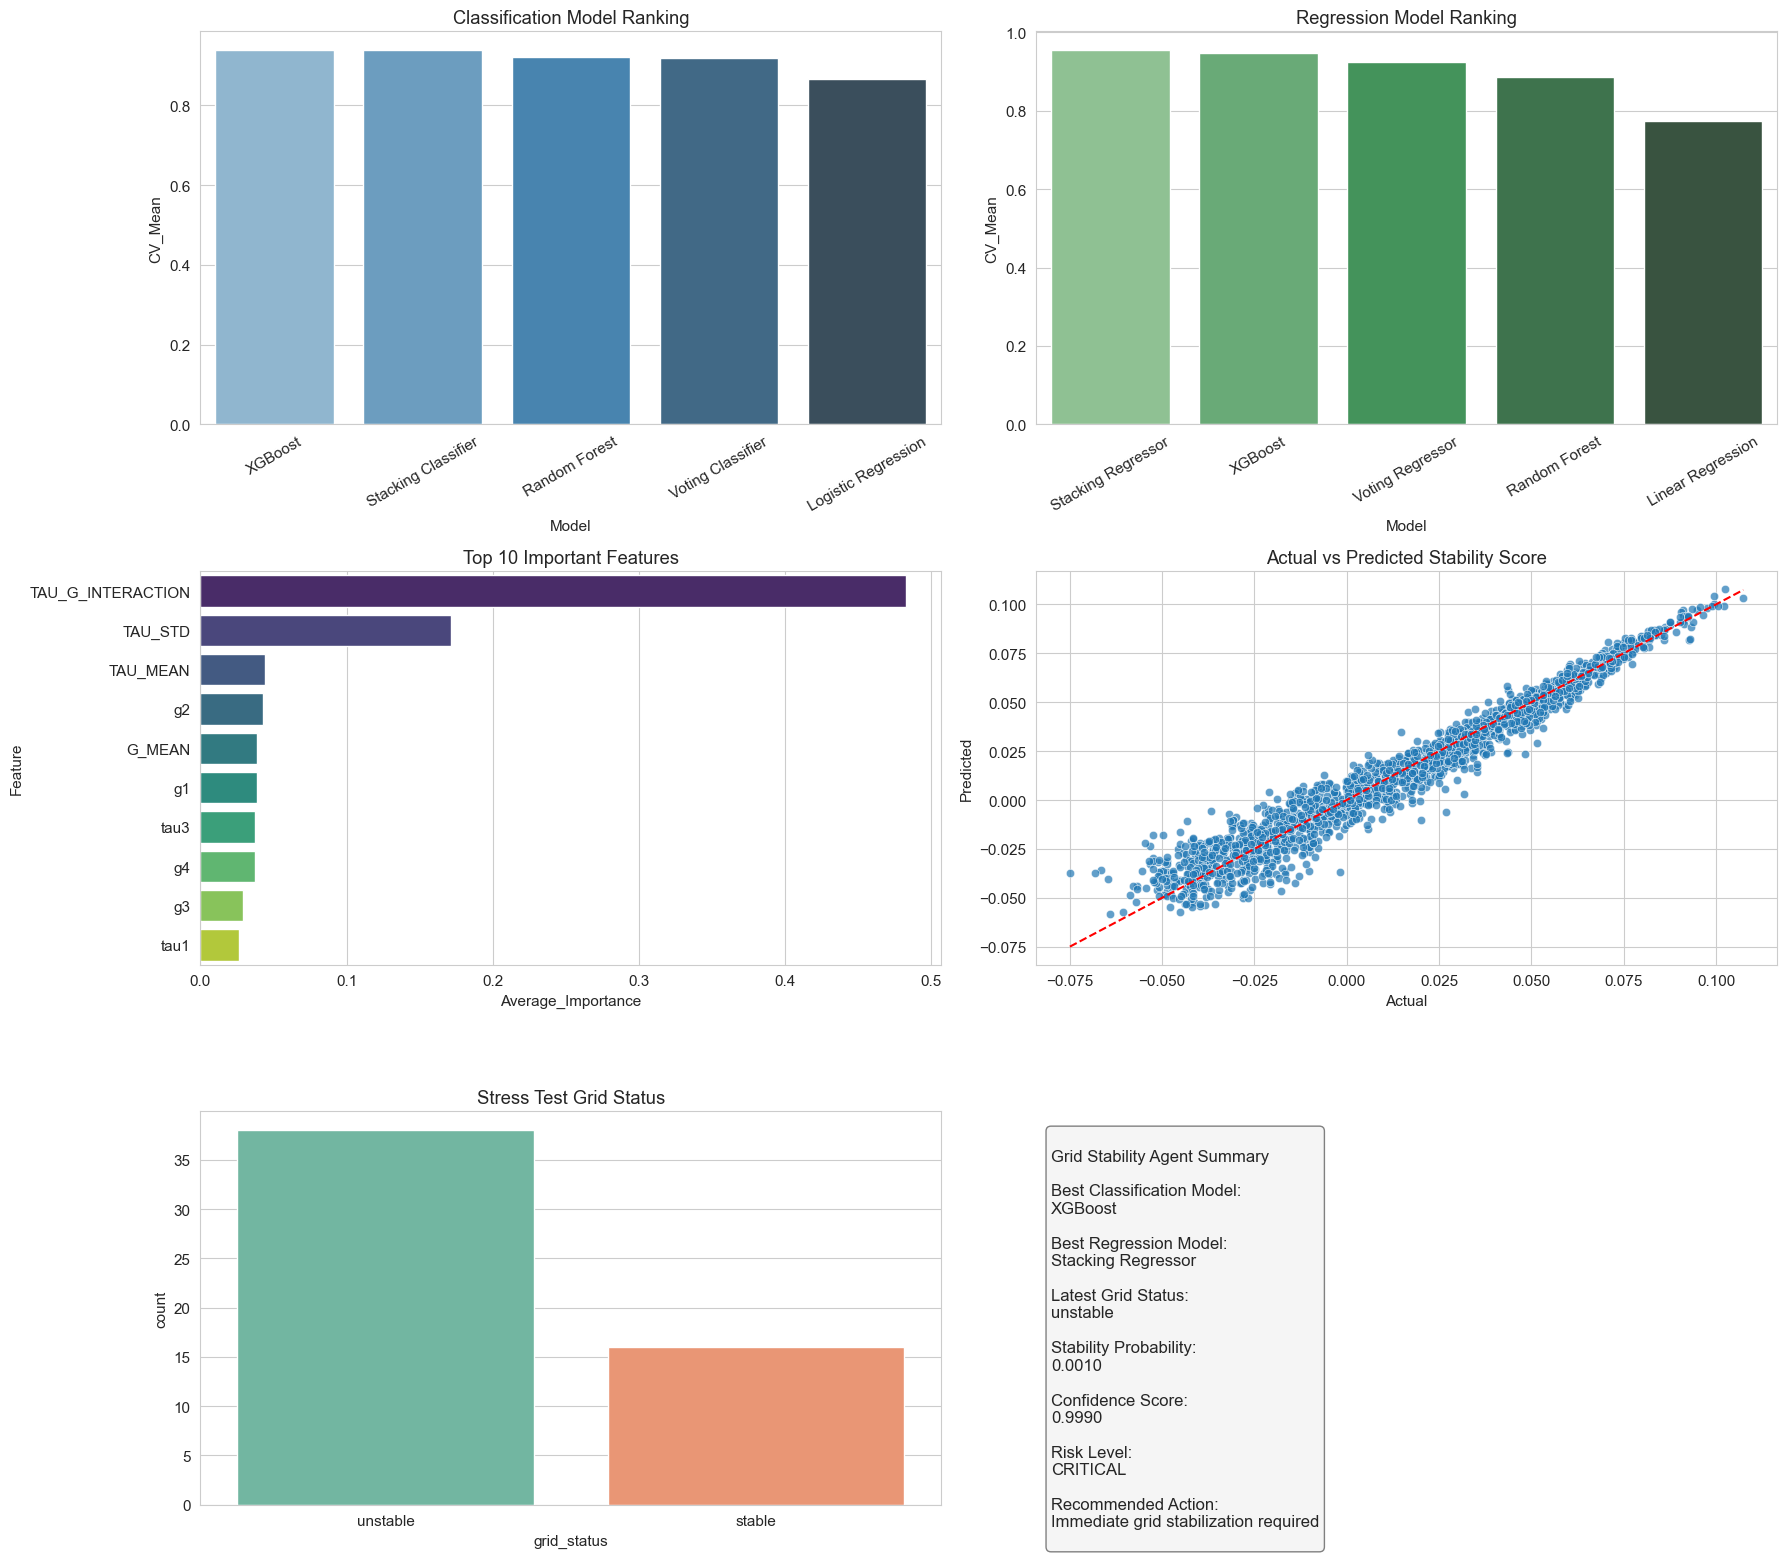

In [40]:
# ============================================================
# SECTION 26: EXECUTIVE DASHBOARD
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 16))

sns.barplot(
    data=classification_ranking,
    x="Model",
    y="CV_Mean",
    ax=axes[0, 0],
    palette="Blues_d"
)
axes[0, 0].set_title("Classification Model Ranking")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=regression_ranking,
    x="Model",
    y="CV_Mean",
    ax=axes[0, 1],
    palette="Greens_d"
)
axes[0, 1].set_title("Regression Model Ranking")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.barplot(
    data=grid_feature_importance.head(10),
    x="Average_Importance",
    y="Feature",
    ax=axes[1, 0],
    palette="viridis"
)
axes[1, 0].set_title("Top 10 Important Features")

sns.scatterplot(
    x=y_reg_test,
    y=best_reg_pred,
    ax=axes[1, 1],
    alpha=0.7
)
axes[1, 1].plot(
    [y_reg_test.min(), y_reg_test.max()],
    [y_reg_test.min(), y_reg_test.max()],
    color="red",
    linestyle="--"
)
axes[1, 1].set_title("Actual vs Predicted Stability Score")
axes[1, 1].set_xlabel("Actual")
axes[1, 1].set_ylabel("Predicted")

sns.countplot(
    data=stress_test_df,
    x="grid_status",
    ax=axes[2, 0],
    palette="Set2"
)
axes[2, 0].set_title("Stress Test Grid Status")

dashboard_text = f"""
Grid Stability Agent Summary

Best Classification Model:
{best_classification_model_name}

Best Regression Model:
{best_regression_model_name}

Latest Grid Status:
{grid_agent_output["grid_status"]}

Stability Probability:
{grid_agent_output["stability_probability"]:.4f}

Confidence Score:
{grid_agent_output["confidence_score"]:.4f}

Risk Level:
{grid_agent_output["risk_level"]}

Recommended Action:
{grid_agent_output["recommended_action"]}
"""

axes[2, 1].axis("off")
axes[2, 1].text(
    0.02,
    0.95,
    dashboard_text,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="gray")
)

plt.tight_layout()
plt.savefig("grid_dashboard.png", dpi=300)
plt.show()

In [41]:
# ============================================================
# SECTION 27: MODEL EXPORT
# ============================================================

joblib.dump(best_classification_model, "grid_classification_best_model.pkl")
joblib.dump(best_regression_model, "grid_regression_best_model.pkl")

grid_agent_bundle = {
    "classification_model": best_classification_model,
    "regression_model": best_regression_model,
    "selected_features": selected_features,
    "classification_model_name": best_classification_model_name,
    "regression_model_name": best_regression_model_name
}

joblib.dump(grid_agent_bundle, "grid_agent.pkl")

with open("grid_features.json", "w") as file:
    json.dump(selected_features, file, indent=4)

print("Models exported successfully.")

Models exported successfully.


In [42]:
# ============================================================
# SECTION 28: RESULTS EXPORT
# ============================================================

classification_ranking.to_csv("grid_classification_metrics.csv", index=False)
regression_ranking.to_csv("grid_regression_metrics.csv", index=False)

grid_model_comparison = pd.concat(
    [classification_ranking, regression_ranking],
    ignore_index=True
)

grid_model_comparison.to_csv("grid_model_comparison.csv", index=False)

best_model_details = pd.DataFrame({
    "Item": [
        "Best Classification Model",
        "Best Regression Model",
        "Classification CV Mean",
        "Classification ROC AUC",
        "Classification F1",
        "Regression CV Mean R2",
        "Regression RMSE",
        "Regression R2"
    ],
    "Value": [
        best_classification_model_name,
        best_regression_model_name,
        classification_ranking.loc[0, "CV_Mean"],
        classification_ranking.loc[0, "ROC_AUC"],
        classification_ranking.loc[0, "F1"],
        regression_ranking.loc[0, "CV_Mean"],
        regression_ranking.loc[0, "RMSE"],
        regression_ranking.loc[0, "R2"]
    ]
})

best_model_details.to_csv("grid_best_model_details.csv", index=False)

save_json(grid_agent_output, "grid_agent_output.json")

coordinator_grid_output = {
    "agent": "grid_stability",
    "status": "success",
    "grid_status": grid_agent_output["grid_status"],
    "confidence": grid_agent_output["confidence_score"],
    "stability_probability": grid_agent_output["stability_probability"],
    "stability_score": grid_agent_output["stability_score"],
    "risk_level": grid_agent_output["risk_level"],
    "recommended_action": grid_agent_output["recommended_action"],
    "timestamp": grid_agent_output["timestamp"]
}

save_json(coordinator_grid_output, "coordinator_grid_output.json")

print("All results exported successfully.")

All results exported successfully.


In [43]:
# ============================================================
# SECTION 29: REPRODUCIBILITY METADATA
# ============================================================

grid_metadata = {
    "project": "Multi-Agent AI Framework for Fossil Fuel Displacement",
    "agent": "Grid Stability Agent",
    "notebook_version": "Final Research Version 1.0",
    "dataset_path": DATASET_PATH,
    "dataset_rows": int(grid_df.shape[0]),
    "dataset_columns": int(grid_df.shape[1]),
    "classification_target": "stabf",
    "regression_target": "stab",
    "selected_features": selected_features,
    "random_seed": RANDOM_STATE,
    "cross_validation_splits": N_SPLITS,
    "smote_applied": bool(apply_smote),
    "best_classification_model": best_classification_model_name,
    "best_regression_model": best_regression_model_name,
    "python_version": sys.version,
    "platform": platform.platform(),
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "training_date": str(pd.Timestamp.now())
}

save_json(grid_metadata, "grid_metadata.json")

In [44]:
# ============================================================
# SECTION 30: RESEARCH REPORT EXPORT
# ============================================================

with pd.ExcelWriter("grid_research_report.xlsx") as writer:
    classification_ranking.to_excel(writer, sheet_name="Classification Models", index=False)
    regression_ranking.to_excel(writer, sheet_name="Regression Models", index=False)
    classification_overfitting.to_excel(writer, sheet_name="Class Overfitting", index=False)
    regression_overfitting.to_excel(writer, sheet_name="Reg Overfitting", index=False)
    feature_ranking.to_excel(writer, sheet_name="Feature Ranking", index=False)
    grid_feature_importance.to_excel(writer, sheet_name="Feature Importance", index=False)
    shap_importance.to_excel(writer, sheet_name="SHAP Importance", index=False)
    grid_outlier_report.to_excel(writer, sheet_name="Outlier Report", index=False)
    stress_test_df.to_excel(writer, sheet_name="Stress Test Results", index=False)
    stress_summary.to_excel(writer, sheet_name="Stress Summary", index=False)
    best_model_details.to_excel(writer, sheet_name="Best Models", index=False)

print("Research report saved as grid_research_report.xlsx")

Research report saved as grid_research_report.xlsx
